In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
UMCG = True

if UMCG:
    MT_preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\ensemble_predictions.csv"
    ST_preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models\all_ST_models_ens_predictions.csv"
    CITOR_preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\LR_ensemble_preds.csv"
else:
    CITOR_preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\LR_ensemble_preds_MDACC_no_UP.csv"
    ST_preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_May25\single_tox_models\all_ST_models_ens_predictions_MDACC_no_UP.csv"
    MT_preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_May25\Trial_32\ensemble_predictions_MDACC_no_UP.csv"

def load_predictions_csv(preds_csv_dir):
    """
    Load predictions from a CSV file.
    """
    df_preds = pd.read_csv(preds_csv_dir, sep=';')
    df_preds['PatientID'] = df_preds['PatientID'].astype(str).str.zfill(7)
    return df_preds

df_preds_MT = load_predictions_csv(MT_preds_csv_dir)
df_preds_ST = load_predictions_csv(ST_preds_csv_dir)
df_preds_CITOR = load_predictions_csv(CITOR_preds_csv_dir)


In [8]:
df_predictions_only_MT = df_preds_MT[['Aspiration_M06_pred', 'Dysphagia_M06_pred', 'Sticky_M06_pred', 'Taste_M06_pred', 'Xerostomia_M06_pred']].copy()
df_predictions_only_MT.columns = df_predictions_only_MT.columns.str.replace('_pred', '', regex=False)
df_predictions_only_MT

df_labels_only_MT = df_preds_MT[['Aspiration_M06_true', 'Dysphagia_M06_true', 'Sticky_M06_true', 'Taste_M06_true', 'Xerostomia_M06_true']].copy()
df_labels_only_MT.columns = df_labels_only_MT.columns.str.replace('_true', '', regex=False)
df_labels_only_MT



df_predictions_only_ST = df_preds_ST[['Aspiration_M06_pred', 'Dysphagia_M06_pred', 'Sticky_M06_pred', 'Taste_M06_pred', 'Xerostomia_M06_pred']].copy()
df_predictions_only_ST.columns = df_predictions_only_ST.columns.str.replace('_pred', '', regex=False)
df_predictions_only_ST

df_labels_only_ST = df_preds_ST[['Aspiration_M06_true', 'Dysphagia_M06_true', 'Sticky_M06_true', 'Taste_M06_true', 'Xerostomia_M06_true']].copy()
df_labels_only_ST.columns = df_labels_only_ST.columns.str.replace('_true', '', regex=False)
df_labels_only_ST

df_predictions_only_CITOR = df_preds_CITOR[['Aspiration_M06_pred', 'Dysphagia_M06_pred', 'Sticky_M06_pred', 'Taste_M06_pred', 'Xerostomia_M06_pred']].copy()
df_predictions_only_CITOR.columns = df_predictions_only_CITOR.columns.str.replace('_pred', '', regex=False)
df_predictions_only_CITOR

df_labels_only_CITOR = df_preds_CITOR[['Aspiration_M06_true', 'Dysphagia_M06_true', 'Sticky_M06_true', 'Taste_M06_true', 'Xerostomia_M06_true']].copy()
df_labels_only_CITOR.columns = df_labels_only_CITOR.columns.str.replace('_true', '', regex=False)
df_labels_only_CITOR

,Aspiration_M06,Dysphagia_M06,Sticky_M06,Taste_M06,Xerostomia_M06
0,0.0,-1.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...
211,0.0,1.0,0.0,0.0,1.0
212,0.0,1.0,0.0,1.0,1.0
213,0.0,0.0,1.0,1.0,1.0
214,1.0,1.0,1.0,1.0,1.0


# ANALYSIS

C:\Users\macraedc\AppData\Local\Temp\ipykernel_22912\925688229.py:78: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\macraedc\AppData\Local\Temp\ipykernel_22912\925688229.py:78: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\macraedc\AppData\Local\Temp\ipykernel_22912\925688229.py:78: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\macraedc\AppData\Local\Temp\ipykernel_22912\925688229.py:78: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is i

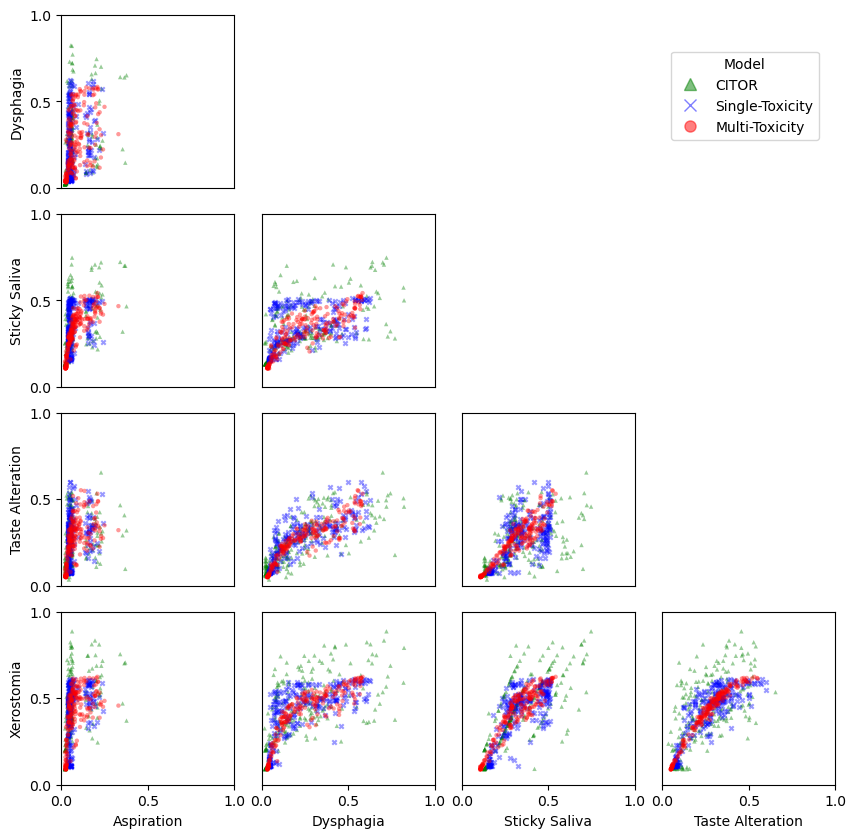

In [ ]:
# Inter-Toxicity Correlation Analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pred_column_names = ['Aspiration_M06', 'Dysphagia_M06', 'Sticky_M06', 'Taste_M06', 'Xerostomia_M06']
plotting_endpoint_names = ['Aspiration', 'Dysphagia', 'Sticky Saliva', 'Taste Alteration', 'Xerostomia']
# Load your predictions DataFrame (replace with actual file path or DataFrame)
#predictions = df_predictions_only.copy()  # Replace with your DataFrame loading code

# ### 1. Prediction Correlation Analysis ###
# # Calculate the pairwise correlation between toxicity predictions
# correlation_matrix = predictions.corr(method='spearman')

# # Plot the correlation heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
# plt.title('Prediction Correlation Matrix')
# plt.show()


df_predictions_only_MT_two = df_predictions_only_MT.copy()
df_predictions_only_MT_two["Model"] = "Multi-Toxicity"
df_predictions_only_ST_two = df_predictions_only_ST.copy()
df_predictions_only_ST_two["Model"] = "Single-Toxicity"
df_predictions_CITOR_two = df_predictions_only_CITOR.copy()
df_predictions_CITOR_two["Model"] = "CITOR"

# Combine the predictions from both models
predictions = pd.concat([df_predictions_CITOR_two, df_predictions_only_ST_two, df_predictions_only_MT_two], ignore_index=True)


# Create scatter plots for each pair of toxicity predictions
toxicity_columns = pred_column_names
num_toxicities = len(toxicity_columns) - 1
# Set square aspect and reduce whitespace between subplots

fig, axes = plt.subplots(
    num_toxicities, num_toxicities,
    figsize=(2.5 * num_toxicities, 2.5 * num_toxicities),  # Square grid
    constrained_layout=False  # We'll use tight_layout below
)

#fig.suptitle('Scatter Plots of DL NTCP Models Predictions', fontsize=16)

catcol = 'Model'
categories = predictions[catcol].value_counts().index.tolist()
colors = ['g', 'b', 'r']
colordict = dict(zip(categories, colors))
predictions["Color"] = predictions[catcol].apply(lambda x: colordict[x])

shapes = ['^', 'x', 'o', ]
shapedict = dict(zip(categories, shapes))
predictions["Shape"] = predictions[catcol].apply(lambda x: shapedict[x])

for i, col1 in enumerate(toxicity_columns[1:]):
    for j, col2 in enumerate(toxicity_columns[:-1]):
        if j > i:
            # Make the upper triangle subfigures invisible
            axes[i, j].set_visible(False)

        ax = axes[i, j]
        ax.set_aspect('equal')  # Make each subplot square

        if i < j:
            ax.set_xticklabels([])
            ax.set_xticks([])
            ax.set_yticklabels([])
            ax.set_yticks([])

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        
        for cat in categories:
            mask = predictions[catcol] == cat
            ax.scatter(
                predictions.loc[mask, col2],
                predictions.loc[mask, col1],
                s=10,
                alpha=0.4,
                c=colordict[cat],
                marker=shapedict[cat],
                label=cat,
                edgecolors='none'
            )

        if j == 0:
            ax.set_ylabel(plotting_endpoint_names[i+1])
            ax.set_yticks([0, 0.5, 1])
            ax.tick_params(axis='y', labelleft=True)
        else:
            ax.set_yticklabels([])
            ax.set_yticks([])

        if i == num_toxicities - 1:
            ax.set_xlabel(plotting_endpoint_names[j])
            ax.set_xticks([0, 0.5, 1])
        else:
            ax.set_xticklabels([])
            ax.set_xticks([])

    # Add legend only once, after the last subplot in the first row
    if i == 0 and j == num_toxicities - 1:
        handles = [
            plt.Line2D(
                [0], [0],
                marker=shapedict[cat],
                color='w',
                label=cat,
                markerfacecolor=colordict[cat],
                markeredgecolor=colordict[cat],
                markersize=8,
                alpha=0.5,
                linestyle='None'
            )
            for cat in categories
        ]
        fig.legend(handles, categories, title=catcol, loc='upper right', bbox_to_anchor=(0.89, 0.85))


fig.subplots_adjust(wspace=0.15, hspace=0.15)
#plt.tight_layout(rect=[0, 0, 1, 0.95], pad=0.5, w_pad=0.2, h_pad=0.2)  # Reduce whitespace

if UMCG:
    plt.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\prediction correlations\ST_MT_preds_scatter_plots_bottom_only.png", dpi=600, bbox_inches='tight')
    plt.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\prediction correlations\ST_MT_preds_scatter_plots_bottom_only.tiff", dpi=600, bbox_inches='tight', format='tiff')
else:
    plt.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\prediction correlations\MDACC_ST_MT_preds_scatter_plots_bottom_only.png", dpi=600, bbox_inches='tight')
    plt.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\prediction correlations\MDACC_ST_MT_preds_scatter_plots_bottom_only.tiff", dpi=600, bbox_inches='tight', format='tiff')

plt.show()